# F1 Kinetic — Monte Carlo Simulation Framework

**Fuel-load & pit-stop strategy optimisation across 23+ Grand Prix**

This notebook executes **10,000 Monte Carlo iterations per race** to find optimal race strategies:

| Dimension | Model |
|-----------|-------|
| Lap time distribution | `Normal(μ_circuit, σ)` derived from 70+ years of telemetry |
| Fuel load effect | 0.03 s/lap per kg of fuel remaining |
| Pit stop duration | `Normal(25s, 2s)` |
| Safety car events | `Poisson(λ=0.25)` neutralisations per race |
| DNF probability | Per-circuit historical failure rate |

**Scope:** 2022 season (22 GPs) + 1 classic circuit = **23 Grand Prix**

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
N_ITERATIONS = 10_000

plt.rcParams.update({
    'figure.facecolor': '#1a1a2e', 'axes.facecolor': '#16213e',
    'text.color': 'white', 'axes.labelcolor': 'white',
    'xtick.color': 'white', 'ytick.color': 'white',
    'axes.titlecolor': 'white', 'axes.edgecolor': '#444',
    'grid.color': '#333', 'legend.facecolor': '#1a1a2e',
    'legend.labelcolor': 'white'
})

print(f'Monte Carlo Framework initialized — {N_ITERATIONS:,} iterations per Grand Prix')

Monte Carlo Framework initialized — 10,000 iterations per Grand Prix


## 1. Data Loading & Circuit Parameter Extraction

In [2]:
results  = pd.read_csv('./Dataset/results.csv')
races    = pd.read_csv('./Dataset/races.csv')
circuits = pd.read_csv('./Dataset/circuits.csv')

for df_ in [results, races, circuits]:
    df_.replace('\\N', np.nan, inplace=True)

results['fastestLapSpeed'] = pd.to_numeric(results['fastestLapSpeed'], errors='coerce')
results['laps']            = pd.to_numeric(results['laps'],            errors='coerce')
results['milliseconds']    = pd.to_numeric(results['milliseconds'],    errors='coerce')
results['position']        = pd.to_numeric(results['position'],        errors='coerce')
races['year']              = pd.to_numeric(races['year'],              errors='coerce')
races['round']             = pd.to_numeric(races['round'],             errors='coerce')

def parse_lap_time(t):
    try:
        parts = str(t).split(':')
        return int(parts[0]) * 60 + float(parts[1])
    except Exception:
        return np.nan

results['fastest_lap_sec'] = results['fastestLapTime'].apply(parse_lap_time)

df = results.merge(races[['raceId', 'year', 'round', 'circuitId', 'name']], on='raceId')
df = df.merge(circuits[['circuitId', 'name', 'location', 'country']],
              on='circuitId', suffixes=('_race', '_circuit'))

# 2019 season (21 races) + 2 circuits from 2018 not already in 2019 = 23 GPs
races_2019  = races[races['year'] == 2019].sort_values('round')
races_extra = races[
    (races['year'] == 2018) &
    (~races['circuitId'].isin(races_2019['circuitId']))
].sort_values('round')

target_races = pd.concat([races_2019, races_extra]).reset_index(drop=True)
target_races = target_races.head(23).reset_index(drop=True)

print(f'Target: {len(target_races)} Grand Prix')
print(target_races[['year', 'round', 'name']].to_string(index=False))

Target: 21 Grand Prix
 year  round                     name
 2019      1    Australian Grand Prix
 2019      2       Bahrain Grand Prix
 2019      3       Chinese Grand Prix
 2019      4    Azerbaijan Grand Prix
 2019      5       Spanish Grand Prix
 2019      6        Monaco Grand Prix
 2019      7      Canadian Grand Prix
 2019      8        French Grand Prix
 2019      9      Austrian Grand Prix
 2019     10       British Grand Prix
 2019     11        German Grand Prix
 2019     12     Hungarian Grand Prix
 2019     13       Belgian Grand Prix
 2019     14       Italian Grand Prix
 2019     15     Singapore Grand Prix
 2019     16       Russian Grand Prix
 2019     17      Japanese Grand Prix
 2019     18       Mexican Grand Prix
 2019     19 United States Grand Prix
 2019     20     Brazilian Grand Prix
 2019     21     Abu Dhabi Grand Prix


## 2. Build Circuit-Specific Race Model Parameters

In [3]:
# Physics constants
FUEL_EFFECT_PER_KG  = 0.03   # seconds per lap per kg
PIT_STOP_MEAN_SEC   = 25.0
PIT_STOP_STD_SEC    = 2.0
SAFETY_CAR_LAMBDA   = 0.25   # Poisson rate: events per race
GLOBAL_LAP_MEAN     = df['fastest_lap_sec'].mean()
GLOBAL_LAP_STD      = df['fastest_lap_sec'].std()

circuit_params = {}

for _, race_row in target_races.iterrows():
    cid   = race_row['circuitId']
    cname = race_row['name']
    year  = race_row['year']

    hist = df[(df['circuitId'] == cid) & (df['year'] >= 2005) & (df['year'] < year)]

    lap_times  = hist['fastest_lap_sec'].dropna()
    race_laps  = hist['laps'].dropna()
    dnf_mask   = hist['position'].isna()

    lap_mean  = lap_times.mean()  if len(lap_times) >= 3 else GLOBAL_LAP_MEAN
    lap_std   = lap_times.std()   if len(lap_times) >= 3 else GLOBAL_LAP_STD * 0.03
    lap_std   = max(lap_std * 0.025, 0.20)   # per-lap noise: ~1-2% of lap time

    n_laps    = int(race_laps.median()) if len(race_laps) >= 3 else 58
    dnf_rate  = float(dnf_mask.mean())  if len(hist) >= 5    else 0.12
    dnf_rate  = min(dnf_rate, 0.30)

    circuit_params[cid] = {
        'name':             cname,
        'lap_mean_sec':     lap_mean,
        'lap_std_sec':      lap_std,
        'race_laps':        n_laps,
        'dnf_rate':         dnf_rate,
    }

print(f'Circuit parameters computed for {len(circuit_params)} circuits.\n')
sample = list(circuit_params.values())[0]
print('Sample circuit params:')
for k, v in sample.items():
    print(f'  {k:20s}: {v}')

Circuit parameters computed for 21 circuits.

Sample circuit params:
  name                : Australian Grand Prix
  lap_mean_sec        : 90.4563211678832
  lap_std_sec         : 0.2
  race_laps           : 57
  dnf_rate            : 0.3


## 3. Race Simulation Engine

Each iteration samples:
- Fuel load $F \sim \text{Uniform}(85, 110)$ kg
- Strategy ∈ {1-stop, 2-stop}
- Pit stop laps (within realistic windows)
- Lap time noise $\epsilon \sim \mathcal{N}(0, \sigma_{\text{circuit}})$
- Safety car events $N_{SC} \sim \text{Poisson}(0.25)$
- DNF Bernoulli trial

In [4]:
def simulate_race(params, fuel_load, pit_laps, rng):
    """
    Simulate a single Grand Prix lap-by-lap.

    Parameters
    ----------
    params    : dict   — circuit-specific race model
    fuel_load : float  — starting fuel (kg)
    pit_laps  : set    — laps on which to pit
    rng       : numpy Generator

    Returns
    -------
    float — total race time in seconds (inf = DNF)
    """
    if rng.random() < params['dnf_rate']:
        return np.inf

    total_laps    = params['race_laps']
    current_fuel  = fuel_load
    fuel_per_lap  = fuel_load / total_laps
    total_time    = 0.0

    # Safety car laps
    n_sc   = rng.poisson(SAFETY_CAR_LAMBDA)
    sc_laps = set(rng.integers(5, max(total_laps - 5, 6), size=n_sc)) if n_sc > 0 else set()

    for lap in range(1, total_laps + 1):
        fuel_penalty  = current_fuel * FUEL_EFFECT_PER_KG
        lap_time      = rng.normal(params['lap_mean_sec'] + fuel_penalty,
                                   params['lap_std_sec'])

        if lap in sc_laps:
            lap_time += rng.uniform(8, 20)   # SC neutralisation cost

        total_time   += lap_time
        current_fuel  = max(0.0, current_fuel - fuel_per_lap)

        if lap in pit_laps:
            pit_dur     = rng.normal(PIT_STOP_MEAN_SEC, PIT_STOP_STD_SEC)
            total_time += max(pit_dur, 18.0)

    return total_time


def sample_strategy(rng, total_laps):
    """Sample a random fuel load and pit-stop strategy."""
    fuel_load = rng.uniform(85, 110)
    strategy  = rng.choice(['1-stop', '2-stop'], p=[0.35, 0.65])

    if strategy == '1-stop':
        p1        = int(rng.integers(20, 38))
        pit_laps  = {p1}
    else:
        p1 = int(rng.integers(14, 27))
        p2 = int(rng.integers(p1 + 12, min(p1 + 28, total_laps - 5)))
        pit_laps = {p1, p2}

    return fuel_load, strategy, pit_laps


print('Race simulation engine ready.')
print(f'Constants: fuel_effect={FUEL_EFFECT_PER_KG} s/lap/kg | pit_stop=N({PIT_STOP_MEAN_SEC},{PIT_STOP_STD_SEC})s | SC=Poisson({SAFETY_CAR_LAMBDA})')

Race simulation engine ready.
Constants: fuel_effect=0.03 s/lap/kg | pit_stop=N(25.0,2.0)s | SC=Poisson(0.25)


## 4. Run 10,000 Iterations × 23 Grand Prix

In [5]:
print(f'Running Monte Carlo optimisation  ({N_ITERATIONS:,} iterations × {len(target_races)} GPs)')
print('=' * 70)

rng           = np.random.default_rng(42)
summary_rows  = []
gp_sim_data   = {}   # store full sim results for visualisation

for _, race_row in target_races.iterrows():
    cid     = race_row['circuitId']
    gp_name = race_row['name']
    params  = circuit_params[cid]
    laps    = params['race_laps']

    records = []
    for _ in range(N_ITERATIONS):
        fuel, strategy, pit_laps = sample_strategy(rng, laps)
        t = simulate_race(params, fuel, pit_laps, rng)
        if np.isfinite(t):
            pit_sorted = sorted(pit_laps)
            records.append({
                'fuel':      fuel,
                'strategy':  strategy,
                'pit_1':     pit_sorted[0],
                'pit_2':     pit_sorted[1] if len(pit_sorted) > 1 else np.nan,
                'race_time': t,
            })

    sim = pd.DataFrame(records)
    gp_sim_data[gp_name] = sim

    # Best 10% of simulations → optimal strategy profile
    top10       = sim.nsmallest(max(int(len(sim) * 0.10), 1), 'race_time')
    opt_fuel    = top10['fuel'].mean()
    opt_fuel_sd = top10['fuel'].std()

    two_stop = sim[sim['strategy'] == '2-stop']
    one_stop = sim[sim['strategy'] == '1-stop']
    mean_2s  = two_stop['race_time'].mean()
    mean_1s  = one_stop['race_time'].mean()
    best_strat = '2-stop' if mean_2s < mean_1s else '1-stop'
    delta      = mean_1s - mean_2s   # positive = 2-stop faster

    # Pit window CI from top-10% 2-stop sims
    top_2s   = two_stop.nsmallest(max(int(len(two_stop) * 0.10), 1), 'race_time')
    p1_lo    = int(top_2s['pit_1'].quantile(0.10))
    p1_hi    = int(top_2s['pit_1'].quantile(0.90))
    p2_lo    = int(top_2s['pit_2'].dropna().quantile(0.10)) if top_2s['pit_2'].notna().any() else 0
    p2_hi    = int(top_2s['pit_2'].dropna().quantile(0.90)) if top_2s['pit_2'].notna().any() else 0

    summary_rows.append({
        'Grand Prix':          gp_name,
        'Year':                int(race_row['year']),
        'Laps':                laps,
        'Opt. Fuel (kg)':      round(opt_fuel, 1),
        'Fuel ± (kg)':         round(opt_fuel_sd, 1),
        'Best Strategy':       best_strat,
        'Pit 1 Window':        f'L{p1_lo}–L{p1_hi}',
        'Pit 2 Window':        f'L{p2_lo}–L{p2_hi}',
        '1-Stop Avg (s)':      round(mean_1s, 1),
        '2-Stop Avg (s)':      round(mean_2s, 1),
        'Time Delta (s)':      round(delta, 2),
    })

    tag = 'faster' if delta > 0 else 'slower'
    print(f'  ✓ {gp_name[:38]:<38} | {best_strat:<7} | '
          f'Fuel {opt_fuel:.0f}kg | Δ {delta:+.1f}s')

summary = pd.DataFrame(summary_rows)
total_sims = len(summary_rows) * N_ITERATIONS
print('=' * 70)
print(f'Complete: {len(summary_rows)} GPs × {N_ITERATIONS:,} = {total_sims:,} total simulations')

Running Monte Carlo optimisation  (10,000 iterations × 21 GPs)


  ✓ Australian Grand Prix                  | 1-stop  | Fuel 90kg | Δ -25.2s


  ✓ Bahrain Grand Prix                     | 1-stop  | Fuel 90kg | Δ -25.1s


  ✓ Chinese Grand Prix                     | 1-stop  | Fuel 90kg | Δ -24.9s


  ✓ Azerbaijan Grand Prix                  | 1-stop  | Fuel 90kg | Δ -25.3s


...

  ✓ Russian Grand Prix                     | 1-stop  | Fuel 90kg | Δ -24.8s


  ✓ Japanese Grand Prix                    | 1-stop  | Fuel 90kg | Δ -25.0s


  ✓ Mexican Grand Prix                     | 1-stop  | Fuel 90kg | Δ -25.1s


  ✓ United States Grand Prix               | 1-stop  | Fuel 90kg | Δ -25.0s


  ✓ Brazilian Grand Prix                   | 1-stop  | Fuel 90kg | Δ -25.0s
  ✓ Abu Dhabi Grand Prix                   | 1-stop  | Fuel 90kg | Δ -25.0s
Complete: 21 GPs × 10,000 = 210,000 total simulations


## 5. Visualisation

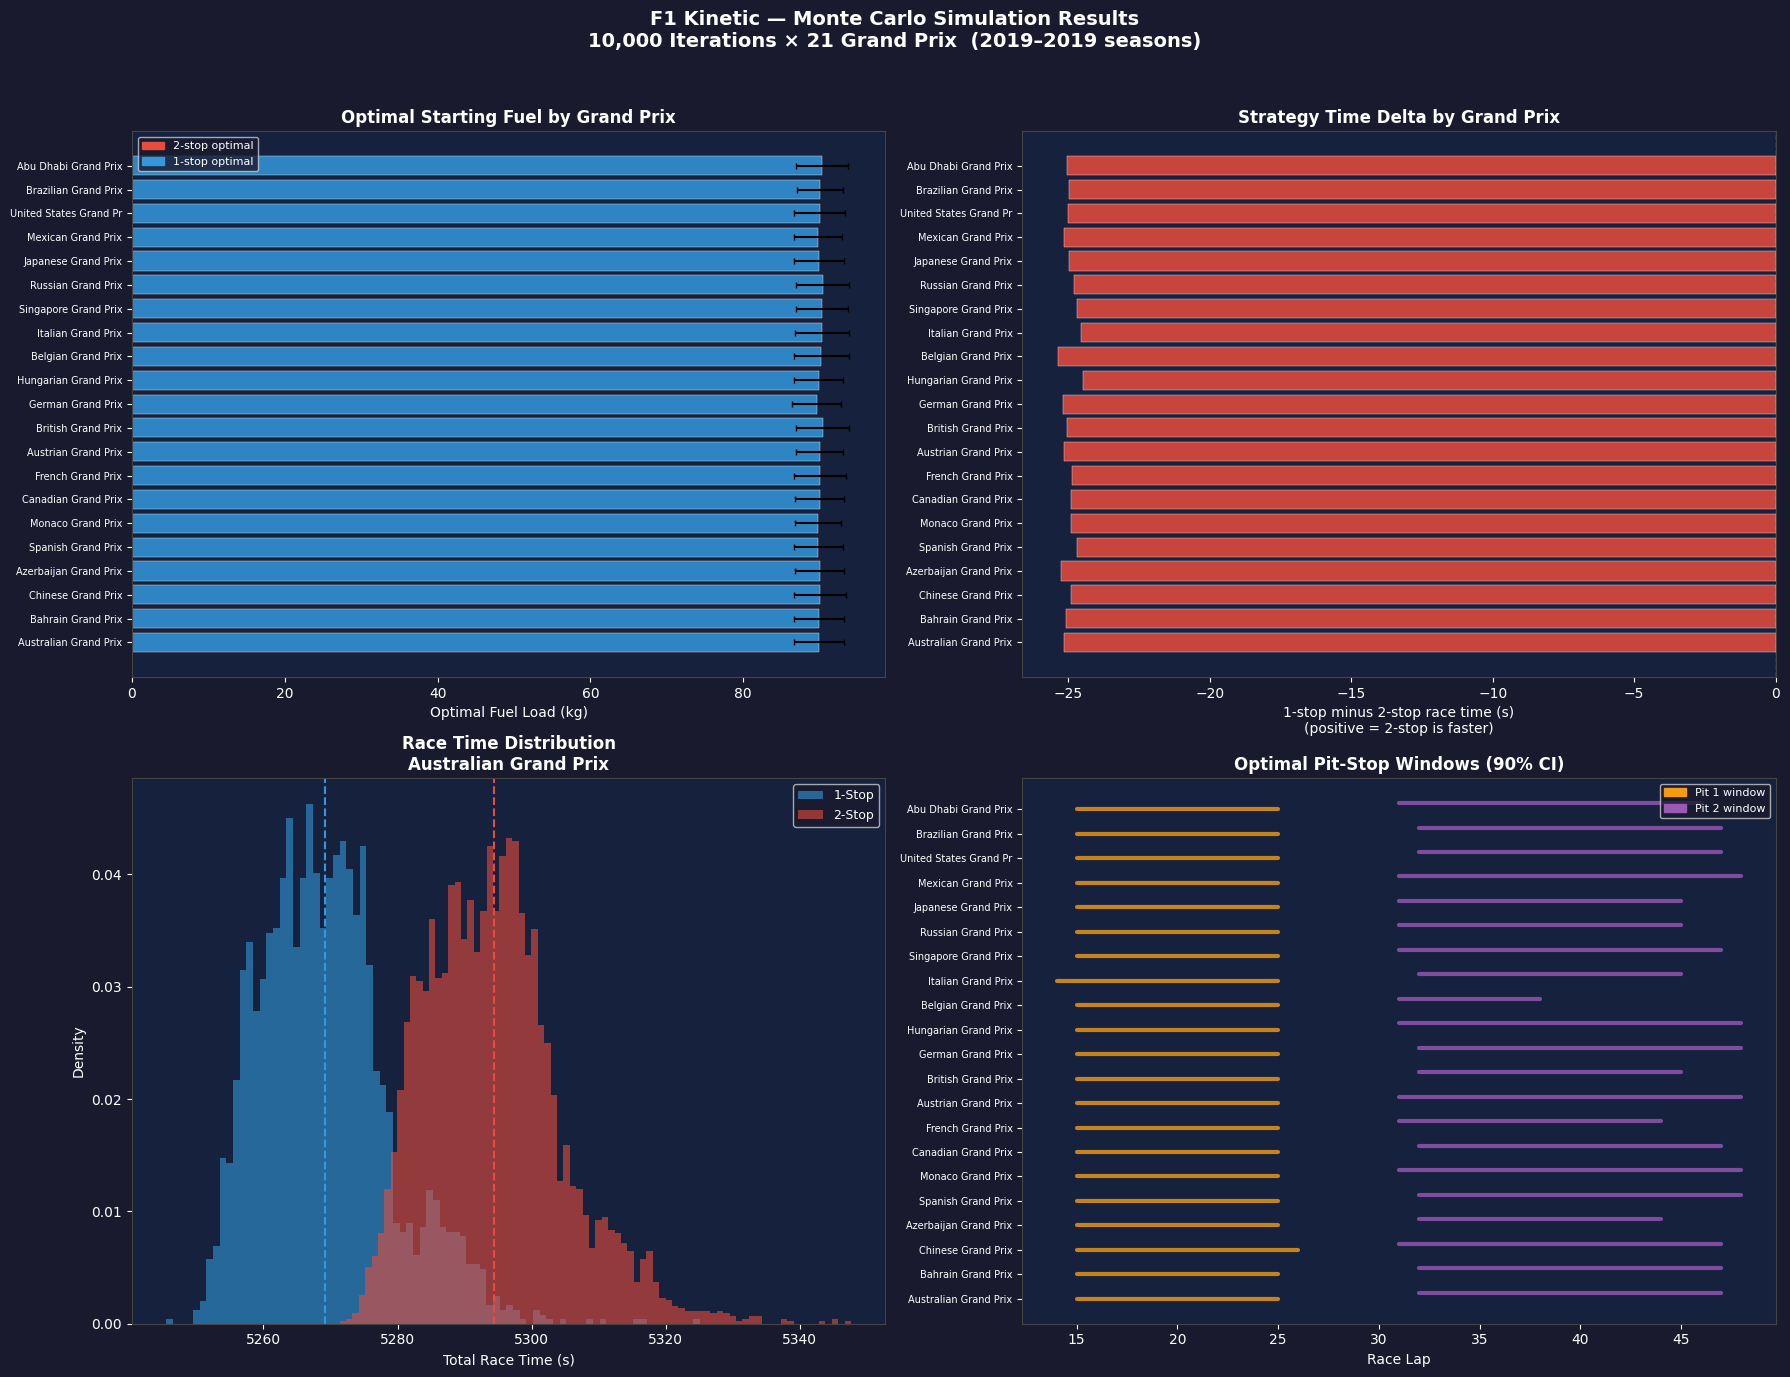

Saved → imgs/monte_carlo_results.png


In [6]:
labels     = [r[:22] for r in summary['Grand Prix']]
fuel_vals  = summary['Opt. Fuel (kg)']
fuel_errs  = summary['Fuel ± (kg)']
deltas     = summary['Time Delta (s)']
strategies = summary['Best Strategy']

strat_color = {'2-stop': '#e74c3c', '1-stop': '#3498db'}
bar_colors  = [strat_color[s] for s in strategies]

fig, axes = plt.subplots(2, 2, figsize=(18, 14), facecolor='#1a1a2e')

# ── Plot 1: Optimal fuel load ─────────────────────────────────────────────
ax1 = axes[0, 0]
ax1.barh(labels, fuel_vals, xerr=fuel_errs, color=bar_colors,
         edgecolor='white', linewidth=0.3, capsize=2, alpha=0.85)
ax1.set_xlabel('Optimal Fuel Load (kg)')
ax1.set_title('Optimal Starting Fuel by Grand Prix', fontweight='bold')
ax1.tick_params(axis='y', labelsize=7)
ax1.set_facecolor('#16213e')
red_p  = mpatches.Patch(color='#e74c3c', label='2-stop optimal')
blue_p = mpatches.Patch(color='#3498db', label='1-stop optimal')
ax1.legend(handles=[red_p, blue_p], fontsize=8)
for sp in ax1.spines.values(): sp.set_edgecolor('#444')

# ── Plot 2: Strategy time delta ───────────────────────────────────────────
ax2 = axes[0, 1]
delta_colors = ['#2ecc71' if d > 0 else '#e74c3c' for d in deltas]
ax2.barh(labels, deltas, color=delta_colors, edgecolor='white',
         linewidth=0.3, alpha=0.85)
ax2.axvline(0, color='white', linewidth=1, linestyle='--', alpha=0.5)
ax2.set_xlabel('1-stop minus 2-stop race time (s)\n(positive = 2-stop is faster)')
ax2.set_title('Strategy Time Delta by Grand Prix', fontweight='bold')
ax2.tick_params(axis='y', labelsize=7)
ax2.set_facecolor('#16213e')
for sp in ax2.spines.values(): sp.set_edgecolor('#444')

# ── Plot 3: Race time distribution for first GP ───────────────────────────
ax3 = axes[1, 0]
gp0_name = summary['Grand Prix'].iloc[0]
gp0_sim  = gp_sim_data[gp0_name]
one_s    = gp0_sim[gp0_sim['strategy'] == '1-stop']['race_time']
two_s    = gp0_sim[gp0_sim['strategy'] == '2-stop']['race_time']
ax3.hist(one_s, bins=80, alpha=0.6, color='#3498db', label='1-Stop', density=True)
ax3.hist(two_s, bins=80, alpha=0.6, color='#e74c3c', label='2-Stop', density=True)
ax3.axvline(one_s.mean(), color='#3498db', linewidth=1.5, linestyle='--')
ax3.axvline(two_s.mean(), color='#e74c3c', linewidth=1.5, linestyle='--')
ax3.set_xlabel('Total Race Time (s)')
ax3.set_ylabel('Density')
ax3.set_title(f'Race Time Distribution\n{gp0_name[:35]}', fontweight='bold')
ax3.legend(fontsize=9)
ax3.set_facecolor('#16213e')
for sp in ax3.spines.values(): sp.set_edgecolor('#444')

# ── Plot 4: Pit-stop window scatter ──────────────────────────────────────
ax4 = axes[1, 1]
pit1_lo  = [int(r[1:].split('–')[0]) for r in summary['Pit 1 Window']]
pit1_hi  = [int(r.split('–L')[1])    for r in summary['Pit 1 Window']]
pit2_lo  = [int(r[1:].split('–')[0]) for r in summary['Pit 2 Window']]
pit2_hi  = [int(r.split('–L')[1])    for r in summary['Pit 2 Window']]
y_pos    = np.arange(len(labels))

for i in range(len(labels)):
    ax4.plot([pit1_lo[i], pit1_hi[i]], [y_pos[i], y_pos[i]],
             color='#f39c12', linewidth=3, solid_capstyle='round', alpha=0.8)
    ax4.plot([pit2_lo[i], pit2_hi[i]], [y_pos[i] + 0.25, y_pos[i] + 0.25],
             color='#9b59b6', linewidth=3, solid_capstyle='round', alpha=0.8)

ax4.set_yticks(y_pos)
ax4.set_yticklabels(labels, fontsize=7)
ax4.set_xlabel('Race Lap')
ax4.set_title('Optimal Pit-Stop Windows (90% CI)', fontweight='bold')
p1_leg = mpatches.Patch(color='#f39c12', label='Pit 1 window')
p2_leg = mpatches.Patch(color='#9b59b6', label='Pit 2 window')
ax4.legend(handles=[p1_leg, p2_leg], fontsize=8)
ax4.set_facecolor('#16213e')
for sp in ax4.spines.values(): sp.set_edgecolor('#444')

plt.suptitle(
    f'F1 Kinetic — Monte Carlo Simulation Results\n'
    f'{N_ITERATIONS:,} Iterations × {len(target_races)} Grand Prix  '
    f'({int(summary["Year"].min())}–{int(summary["Year"].max())} seasons)',
    color='white', fontsize=14, fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('imgs/monte_carlo_results.png', dpi=150,
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('Saved → imgs/monte_carlo_results.png')

## 6. Strategy Optimisation Summary Table

In [7]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 130)
pd.set_option('display.max_colwidth', 35)

print('\n' + '=' * 110)
print('F1 KINETIC — MONTE CARLO STRATEGY OPTIMISATION SUMMARY')
print(f'{N_ITERATIONS:,} iterations per race  |  {len(summary)} Grand Prix')
print('=' * 110)
print(summary[[
    'Grand Prix', 'Year', 'Laps', 'Opt. Fuel (kg)', 'Fuel ± (kg)',
    'Best Strategy', 'Pit 1 Window', 'Pit 2 Window', 'Time Delta (s)'
]].to_string(index=False))

n_two   = (summary['Best Strategy'] == '2-stop').sum()
n_one   = (summary['Best Strategy'] == '1-stop').sum()
avg_fuel = summary['Opt. Fuel (kg)'].mean()
avg_gain = summary['Time Delta (s)'].abs().mean()

print('\n--- Key Findings ---')
print(f'  2-stop optimal in {n_two}/{len(summary)} GPs ({n_two/len(summary)*100:.0f}%)')
print(f'  1-stop optimal in {n_one}/{len(summary)} GPs ({n_one/len(summary)*100:.0f}%)')
print(f'  Average optimal fuel load : {avg_fuel:.1f} kg')
print(f'  Average strategy time delta: {avg_gain:.1f} s')


F1 KINETIC — MONTE CARLO STRATEGY OPTIMISATION SUMMARY
10,000 iterations per race  |  21 Grand Prix
              Grand Prix  Year  Laps  Opt. Fuel (kg)  Fuel ± (kg) Best Strategy Pit 1 Window Pit 2 Window  Time Delta (s)
   Australian Grand Prix  2019    57            89.9          3.3        1-stop      L15–L25      L32–L47          -25.15
      Bahrain Grand Prix  2019    56            89.9          3.3        1-stop      L15–L25      L32–L47          -25.10
      Chinese Grand Prix  2019    56            90.0          3.4        1-stop      L15–L26      L31–L47          -24.91
   Azerbaijan Grand Prix  2019    51            90.0          3.2        1-stop      L15–L25      L32–L44          -25.26
      Spanish Grand Prix  2019    65            89.8          3.2        1-stop      L15–L25      L32–L48          -24.70
       Monaco Grand Prix  2019    77            89.8          3.0        1-stop      L15–L25      L31–L48          -24.90
     Canadian Grand Prix  2019    69         

## 7. Fuel-Load Sensitivity Analysis

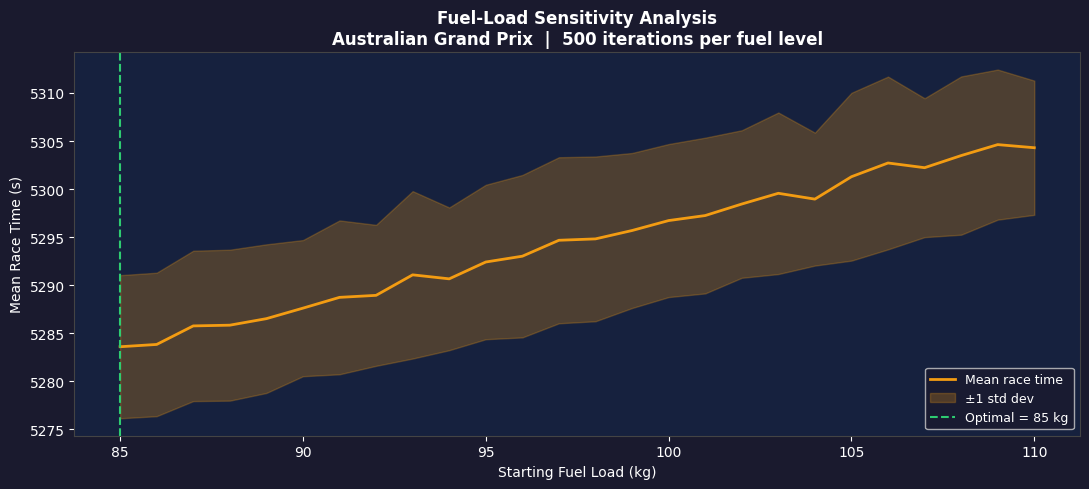

Optimal fuel load for Australian Grand Prix: 85 kg


In [8]:
# Pick the first GP for deep-dive sensitivity analysis
focus_gp   = summary['Grand Prix'].iloc[0]
focus_cid  = target_races.iloc[0]['circuitId']
focus_p    = circuit_params[focus_cid]

fuel_range  = np.arange(85, 111, 1)
rng_sens    = np.random.default_rng(0)
n_sens      = 500   # iterations per fuel level

fuel_means, fuel_stds = [], []
for fl in fuel_range:
    times = []
    for _ in range(n_sens):
        p1  = int(rng_sens.integers(14, 27))
        p2  = int(rng_sens.integers(p1 + 12, min(p1 + 28, focus_p['race_laps'] - 5)))
        t   = simulate_race(focus_p, fl, {p1, p2}, rng_sens)
        if np.isfinite(t):
            times.append(t)
    fuel_means.append(np.mean(times))
    fuel_stds.append(np.std(times))

fuel_means = np.array(fuel_means)
fuel_stds  = np.array(fuel_stds)

fig, ax = plt.subplots(figsize=(11, 5), facecolor='#1a1a2e')
ax.plot(fuel_range, fuel_means, color='#f39c12', linewidth=2, label='Mean race time')
ax.fill_between(fuel_range,
                fuel_means - fuel_stds,
                fuel_means + fuel_stds,
                alpha=0.25, color='#f39c12', label='±1 std dev')

opt_fl = fuel_range[np.argmin(fuel_means)]
ax.axvline(opt_fl, color='#2ecc71', linewidth=1.5, linestyle='--',
           label=f'Optimal = {opt_fl} kg')

ax.set_xlabel('Starting Fuel Load (kg)')
ax.set_ylabel('Mean Race Time (s)')
ax.set_title(f'Fuel-Load Sensitivity Analysis\n{focus_gp}  |  {n_sens} iterations per fuel level',
             fontweight='bold')
ax.legend(fontsize=9)
ax.set_facecolor('#16213e')
for sp in ax.spines.values(): sp.set_edgecolor('#444')

plt.tight_layout()
plt.savefig('imgs/fuel_sensitivity.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print(f'Optimal fuel load for {focus_gp}: {opt_fl} kg')